# **Creación de data tabular de la señales fisiológicas obtenidas de EMG y ECG**

In [4]:
#Importación de librerías
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
#Seleccionamos estilo de ploteo
plt.style.use("ggplot")

## Lectura de los datos ECG

In [6]:
#Lectura de documento txt con tabulación (/t) como delimitador
array1 = np.genfromtxt("./señal ecg1.txt", delimiter=",",skip_header = 2)
array2 = np.genfromtxt("./señal ecg1.txt", delimiter=",",skip_header = 2)

array([[0.000e+00, 5.270e+02],
       [1.000e-02, 5.310e+02],
       [2.000e-02, 5.260e+02],
       ...,
       [9.492e+01, 4.960e+02],
       [9.493e+01, 5.360e+02],
       [9.494e+01, 4.970e+02]])

In [7]:
#Nos quedamos con el dato del sensor
array1[:,0] = np.arange(0, len(array1[:,0]))
basal1 = array1[500:1500,1]
inhex5s = array1[3500:4500,1]
basal2 = array1[7500:8500,1]

array2[:,0] = np.arange(0, len(array1[:,0]))
basal1 = array1[500:1500,1]
inhex5s = array1[3500:4500,1]
basal2 = array1[7500:8500,1]

## Graficación de los datos ECG

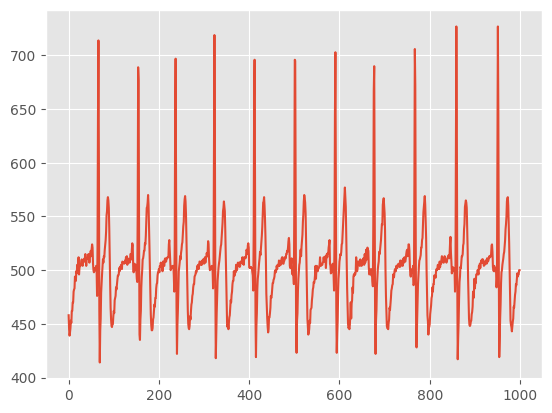

In [8]:
plt.plot(basal1)

## Especificar la Frecuencia de muestreo para medicion ECG 

---



In [9]:
Fs = 100 #Frecuencia de muestreo del dispositivo de adquisición
Ts=1/Fs
n = np.arange(0,basal1.shape[0])  # t = n*Ts
t = n*Ts

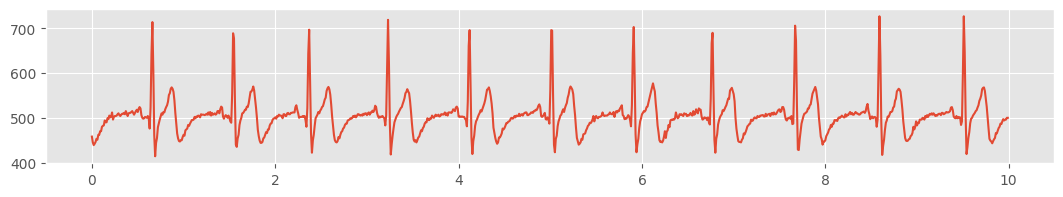

In [10]:
#Ploteamos la señal en el tiempo
plt.figure(figsize=(13,2)) #Modificamos el tamaño de la gráfica
plt.plot(t, basal1)

## Pasando a data tabular estilo Sklearn

In [11]:
def deefe(array:np.array,ntarget:int):
  #Pasamos las observaciones a filas correspondientes a una variable t y d_sensor
  st_sensor = np.concatenate((t.reshape(-1,1),  array.reshape(-1,1)), axis=1)
  #Creamos el data frame con las varibles t y d_sensor
  df = pd.DataFrame(st_sensor, columns=["t","d_sensor"])
  df.head()
  #Establecemos t como index 
  df = df.set_index("t")
  df.head()

  d_obs = df[["d_sensor"]].values.reshape(10,100)
  target = np.repeat(ntarget, d_obs.shape[0])
  return d_obs,target

obs_basal1,target_basal1=deefe(basal1,0)
obs_inhex5s,target_inhex5s=deefe(inhex5s,1)
obs_basal2,target_basal2=deefe(basal2,2)

## Descripción de categoria de los ejercicios realizado en la clase de ECG

| Descripción | Categoria |
|----------|----------|
| Basal    | 0   |
| Respiracion   | 1   | 
| Post-Ejercicio    | 2   |



> *   **Basal:** Medicion en reposo basal. 
*   **Post-ejercicio:** Medicion inmediatamente despues de la repeticion de 20 burpees.
* **Respiración**: Medicion de ciclo de 3 repeticiones de inhalación y exhalación, con un 
aguante de 5 segundos por proceso.
*   **Respiración post-ejercicio:** Medicion de ciclo de 2 repeticiones de inhalación y exhalación con un aguante de 10 segundos.




In [12]:
ecg = {"base": [obs_basal1,obs_inhex5s,obs_basal2], "target": [target_basal1,target_inhex5s,target_basal2]}
ecg

{'base': [array([[458., 445., 439., 442., 446., 453., 451., 462., 462., 470., 470.,
          480., 482., 483., 494., 490., 490., 499., 497., 505., 501., 503.,
          512., 496., 502., 504., 504., 505., 508., 510., 506., 504., 507.,
          509., 509., 511., 508., 515., 510., 504., 510., 511., 511., 513.,
          515., 511., 507., 511., 515., 518., 513., 520., 524., 521., 506.,
          500., 498., 499., 502., 501., 500., 504., 499., 476., 523., 643.,
          714., 606., 462., 414., 444., 455., 479., 488., 496., 503., 510.,
          507., 513., 512., 519., 524., 528., 536., 551., 555., 565., 568.,
          565., 558., 539., 511., 487., 465., 454., 448., 447., 450., 450.,
          457.],
         [462., 460., 472., 474., 476., 484., 482., 487., 491., 495., 495.,
          496., 502., 499., 503., 502., 505., 504., 501., 508., 507., 507.,
          507., 506., 507., 509., 507., 512., 507., 513., 505., 511., 507.,
          508., 510., 507., 509., 515., 515., 510., 519., 525.,